# Imports

In [ ]:
# Standard Library Imports
import os
import re
import time
import random
import tempfile
import warnings
from abc import ABC, abstractmethod
from typing import Any, Dict, List, Tuple
from tqdm.auto import tqdm
from tqdm_joblib import tqdm_joblib


# Data Processing & Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Machine Learning & NLP
from datasets import load_dataset
import torch
import fasttext
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV
from scipy.stats import loguniform
import joblib


sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using runtime execution target: {device.upper()}")
if device == "cuda":
    print(f"GPU Name:     {torch.cuda.get_device_name(0)}")
    free, total = torch.cuda.mem_get_info()
    print(f"Total Memory: {total / 1024**3:.2f} GB")
    print(f"Free Memory:  {free / 1024**3:.2f} GB")

Using runtime execution target: CPU


# Data Preprocessing

In [5]:
# 1. Load the specific dataset from Hugging Face Hub
dataset_dict = load_dataset("papluca/language-identification")

# 2. Map structural Arrow splits cleanly into Pandas DataFrames
train_df = dataset_dict['train'].to_pandas()
val_df = dataset_dict['validation'].to_pandas()
test_df = dataset_dict['test'].to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/4.99k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/12.0M [00:00<?, ?B/s]

valid.csv:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/1.69M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [6]:
print(f"Ingestion successful!\nTrain Rows: {len(train_df)} | Val Rows: {len(val_df)} | Test Rows: {len(test_df)}")

Ingestion successful!
Train Rows: 70000 | Val Rows: 10000 | Test Rows: 10000


In [7]:
train_df.head()

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [8]:
LANG_MAP = {
    'ar': 'Arabic', 'bg': 'Bulgarian', 'de': 'German', 'el': 'Modern Greek',
    'en': 'English', 'es': 'Spanish', 'fr': 'French', 'hi': 'Hindi',
    'it': 'Italian', 'ja': 'Japanese', 'nl': 'Dutch', 'pl': 'Polish',
    'pt': 'Portuguese', 'ru': 'Russian', 'sw': 'Swahili', 'th': 'Thai',
    'tr': 'Turkish', 'ur': 'Urdu', 'vi': 'Vietnamese', 'zh': 'Chinese'
}

In [9]:
train_df['language_name'] = train_df['labels'].map(LANG_MAP)
val_df['language_name'] = val_df['labels'].map(LANG_MAP)
test_df['language_name'] = test_df['labels'].map(LANG_MAP)

In [10]:
train_df.head()

,labels,text,language_name
0,pt,"os chefes de defesa da estónia, letónia, lituâ...",Portuguese
1,bg,размерът на хоризонталната мрежа може да бъде ...,Bulgarian
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...,Chinese
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...,Thai
4,ru,Он увеличил давление .,Russian


In [11]:
counts_per_label = train_df.groupby('language_name').size().sort_values(ascending=False)

print("Counts per Label:")
print(counts_per_label)

Counts per Label:
language_name
Arabic          3500
Bulgarian       3500
Chinese         3500
Dutch           3500
English         3500
French          3500
German          3500
Hindi           3500
Italian         3500
Japanese        3500
Modern Greek    3500
Polish          3500
Portuguese      3500
Russian         3500
Spanish         3500
Swahili         3500
Thai            3500
Turkish         3500
Urdu            3500
Vietnamese      3500
dtype: int64


<font color='lightgreen'>Note: </font> Dataset is balanced

In [12]:
train_df.describe().T

,count,unique,top,freq
labels,70000,20,pt,3500
text,70000,68978,Een man speelt gitaar.,18
language_name,70000,20,Portuguese,3500


<font color='lightgreen'>Note: </font> There are duplicates in the text

In [13]:
train_df['text'].duplicated().sum()

np.int64(1022)

In [14]:
train_df.duplicated().sum()

np.int64(1020)

In [15]:
multi_labels_text = train_df[train_df['text'].duplicated() != train_df.duplicated()]['text']

In [16]:
train_df[train_df['text'].isin(multi_labels_text.to_list())]

,labels,text,language_name
5551,pl,Snowden Hits Hurdles in Search for Asylum,Polish
20561,nl,Snowden Hits Hurdles in Search for Asylum,Dutch
51539,pt,Santorum Romping To Minnesota Victory,Portuguese
53666,nl,Santorum Romping To Minnesota Victory,Dutch


<font color='lightgreen'>Note: </font> Found 2 instances of more than one label.

In [17]:
def report_and_visualize_duplicates(df: pd.DataFrame, label_col: str = 'language_name') -> int:
    """
    Analyzes internal row duplication within a DataFrame, breaks down duplicates
    by class labels, and generates a visual quality report.
    """
    total_duplicates = df['text'].duplicated().sum()
    print(f"--- Dataset Duplicate Analysis ---")
    print(f"Total exact duplicate texts found: {total_duplicates}")

    if total_duplicates == 0:
        print("No duplicates detected. Skipping visualization.")
        return total_duplicates

    # Count the total number of duplicate rows for every label
    duplicate_counts_per_label = df[df.duplicated()].groupby(label_col).size().sort_values(ascending=False)

    print("\nDuplicate Counts per Label:")
    print(duplicate_counts_per_label)

    # Plot using a sequential color palette
    plt.figure(figsize=(12, 8))
    ax = sns.barplot(
        x=duplicate_counts_per_label.values,
        y=duplicate_counts_per_label.index,
        palette="Blues_r",
        edgecolor="black",
        hue=duplicate_counts_per_label.index, # Avoids Seaborn future warnings
        legend=False
    )

    plt.title('Data Quality Report: Duplicate Rows by Language', fontsize=16, pad=15, weight='bold')
    plt.xlabel('Number of Duplicate Rows', fontsize=12, labelpad=10)
    plt.ylabel('Language Labels', fontsize=12)

    # Clean UI lines
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

    return total_duplicates

--- Dataset Duplicate Analysis ---
Total exact duplicate texts found: 1022

Duplicate Counts per Label:
language_name
Polish          166
Dutch           160
Italian         154
Portuguese      150
Urdu             44
Russian          37
Swahili          37
Thai             37
Modern Greek     37
Arabic           36
Bulgarian        36
Vietnamese       36
Turkish          36
Hindi            36
Chinese           9
French            5
Spanish           2
English           1
German            1
dtype: int64


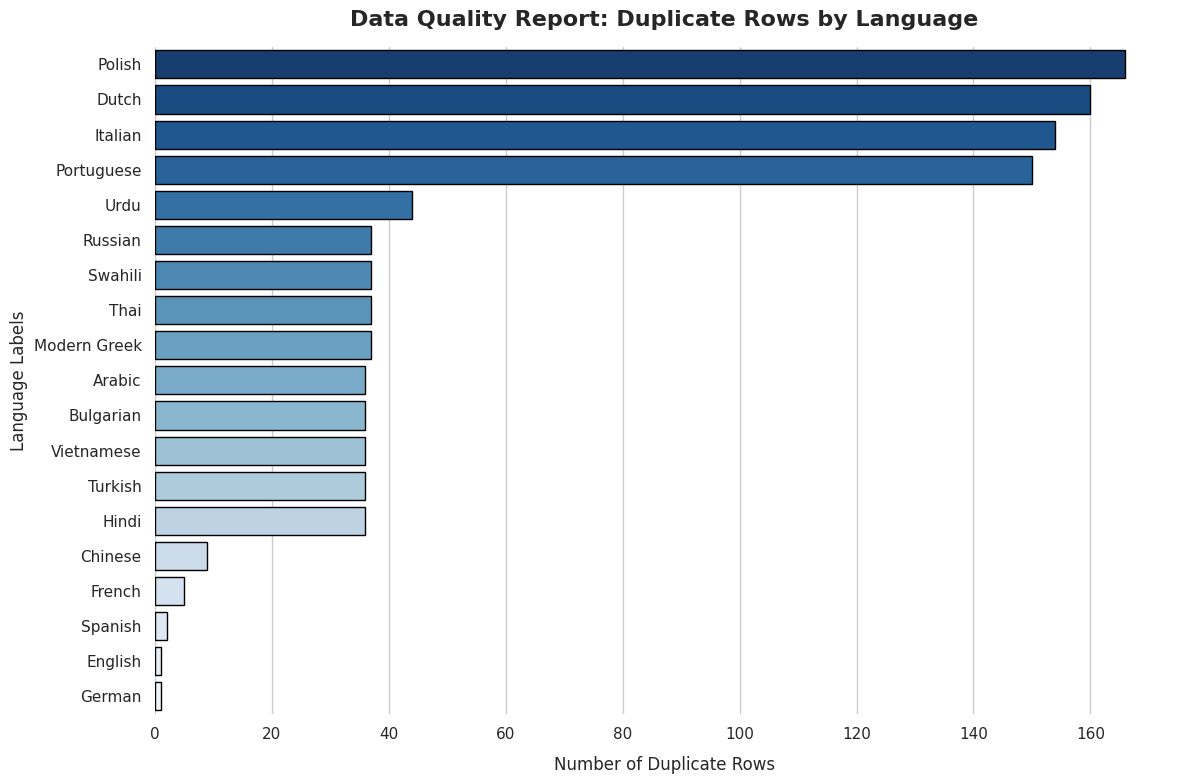

np.int64(1022)

In [18]:
report_and_visualize_duplicates(train_df)

--- Dataset Duplicate Analysis ---
Total exact duplicate texts found: 1010

Duplicate Counts per Label:
language_name
Arabic          98
Bulgarian       98
Hindi           98
Modern Greek    98
Russian         98
Swahili         98
Urdu            98
Vietnamese      98
Turkish         98
Thai            98
Portuguese       8
Dutch            8
Italian          7
Polish           7
dtype: int64


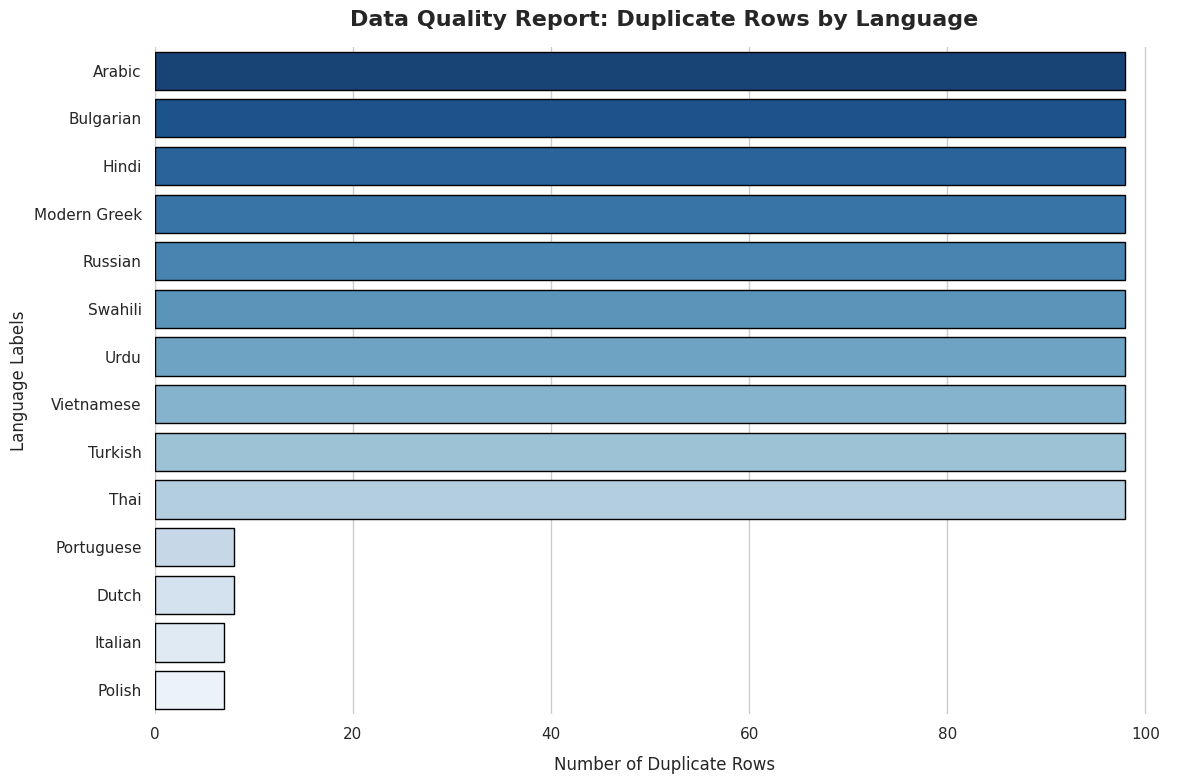

np.int64(1010)

In [19]:
report_and_visualize_duplicates(val_df)

--- Dataset Duplicate Analysis ---
Total exact duplicate texts found: 667

Duplicate Counts per Label:
language_name
Arabic          60
Bulgarian       60
Hindi           60
Modern Greek    60
Russian         60
Swahili         60
Urdu            60
Vietnamese      60
Turkish         60
Thai            60
Polish          19
Dutch           16
Italian         16
Portuguese      16
dtype: int64


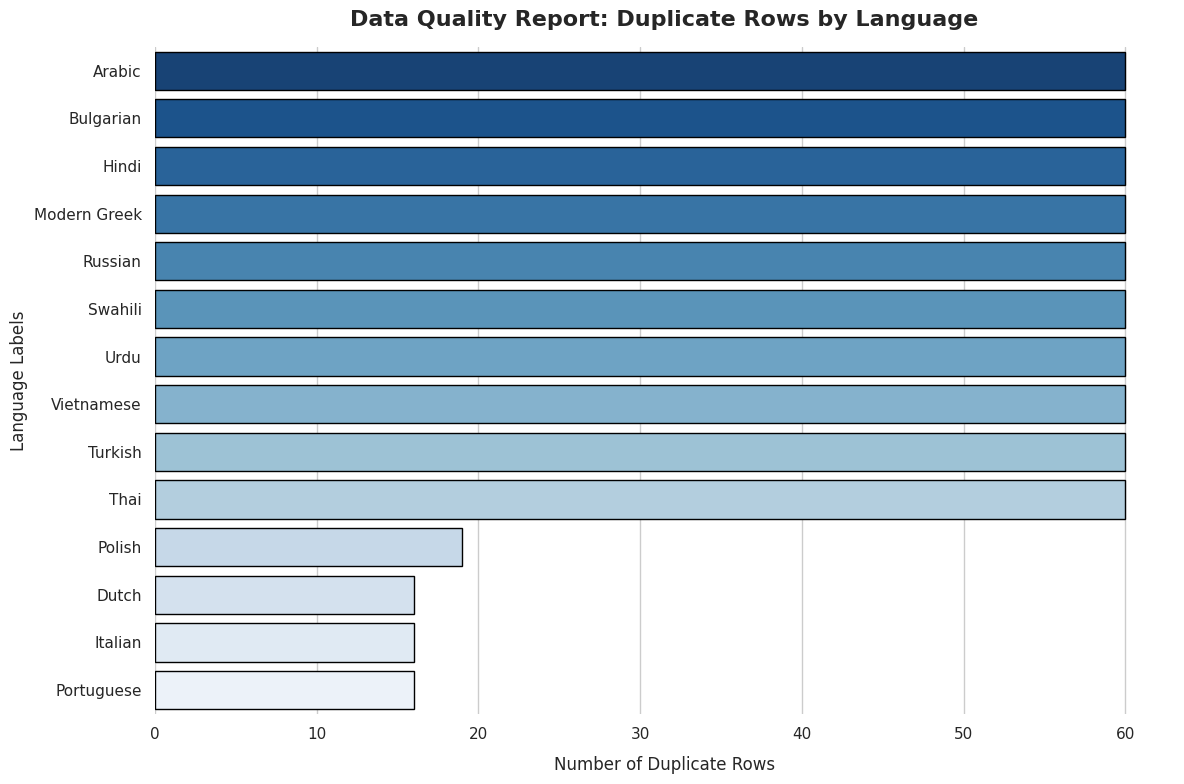

np.int64(667)

In [20]:
report_and_visualize_duplicates(test_df)

<font color='lightgreen'>Note: </font> Dataset not balanced 😞

In [21]:
def clean_and_deduplicate_splits(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    text_col: str = 'text'
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Performs data validation and leakage cleaning across data splits:
    1. Removes internal duplicate texts from validation and test sets.
    2. Audits and prints cross-split overlap (leakage) counts.
    3. Purges overlapping evaluation items from the training set to protect split isolation.
    4. Resets indices to prevent downstream model misalignment.
    """
    print("\n" + "="*50)
    print("STARTING DATA LEAKAGE CLEANING PIPELINE")
    print("="*50)

    # 1. Clean Validation and Test sets internally
    train_cleaned = train_df.drop_duplicates(subset=text_col, keep='first').copy()
    val_cleaned = val_df.drop_duplicates(subset=text_col, keep='first').copy()
    test_cleaned = test_df.drop_duplicates(subset=text_col, keep='first').copy()

    original_unique_train_size = len(train_cleaned)
    original_unique_val_size = len(val_cleaned)
    original_unique_test_size = len(test_cleaned)

    print(f"Original Train Size: {len(train_df)}")
    print(f"Original Val Size: {len(train_df)}")
    print(f"Original Test Size: {len(train_df)}")

    print(f"Baseline Unique Train Size: {original_unique_train_size}")
    print(f"Baseline Unique Val Size: {original_unique_val_size}")
    print(f"Baseline Unique Test Size: {original_unique_test_size}")

    # 2. Audit Cross-Split Data Overlaps
    overlap_train_val = val_cleaned[text_col].isin(train_cleaned[text_col]).sum()
    overlap_train_test = test_cleaned[text_col].isin(train_cleaned[text_col]).sum()
    overlap_val_test = test_cleaned[text_col].isin(val_cleaned[text_col]).sum()

    print(f"-> Overlaps between Train set and Val set:  {overlap_train_val}")
    print(f"-> Overlaps between Train set and Test set: {overlap_train_test}")
    print(f"-> Overlaps between Val set and Test set:   {overlap_val_test}")

    # 3. Purge Leakage from Training Set
    # Keep only rows whose text is NOT present in validation or test data spaces
    train_cleaned = train_cleaned[~train_cleaned[text_col].isin(val_cleaned[text_col])].reset_index(drop=True)
    train_cleaned = train_cleaned[~train_cleaned[text_col].isin(test_cleaned[text_col])].reset_index(drop=True)
    val_cleaned   = val_cleaned  [~val_cleaned[text_col].isin(test_cleaned[text_col])].reset_index(drop=True)

    final_train_size = len(train_cleaned)
    final_val_size = len(val_cleaned)
    final_test_size = len(test_cleaned)

    removed_training_items = original_unique_train_size - final_train_size
    removed_val_items      = original_unique_val_size - final_val_size
    removed_test_items     = original_unique_test_size - final_test_size

    print("="*50)
    print(f"Cleaned Train Size:  {final_train_size}")
    print(f"Removed Overlaps:    {removed_training_items}")
    print("="*50)
    print(f"Cleaned Val Size:  {final_val_size}")
    print(f"Removed Overlaps:    {removed_val_items}")
    print("="*50)
    print(f"Cleaned Test Size:  {final_test_size}")
    print(f"Removed Overlaps:    {removed_test_items}")
    print("="*50 + "\n")

    return train_cleaned, val_cleaned, test_cleaned

In [22]:
train_cleaned, val_cleaned, test_cleaned = clean_and_deduplicate_splits(train_df, val_df, test_df)


STARTING DATA LEAKAGE CLEANING PIPELINE
Original Train Size: 70000
Original Val Size: 70000
Original Test Size: 70000
Baseline Unique Train Size: 68978
Baseline Unique Val Size: 8990
Baseline Unique Test Size: 9333
-> Overlaps between Train set and Val set:  112
-> Overlaps between Train set and Test set: 150
-> Overlaps between Val set and Test set:   31
Cleaned Train Size:  68736
Removed Overlaps:    242
Cleaned Val Size:  8959
Removed Overlaps:    31
Cleaned Test Size:  9333
Removed Overlaps:    0



In [23]:
train_cleaned.describe().T

,count,unique,top,freq
labels,68736,20,ja,3500
text,68736,68736,да деля спалнята си .,1
language_name,68736,20,Japanese,3500


# Experiments

In [24]:
class BaseLanguageDetector(ABC):
    """
    Abstract Base Class enforcing uniform signatures across all
    traditional ML, subword, and hierarchical routing architectures.
    """
    @abstractmethod
    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame = None) -> None:
        """Train the underlying model using a consistent dataframe schema containing 'text' and 'labels'."""
        pass

    @abstractmethod
    def predict(self, text: str) -> str:
        """Infer the single language ISO code for a standalone user query text string."""
        pass

    @abstractmethod
    def save(self, target_path: str) -> None:
        """Serializes internal weights and pipeline definitions to static storage."""
        pass

    @abstractmethod
    def load(self, source_path: str) -> None:
        """Deserializes external structural assets back into active memory blocks."""
        pass

    def calculate_inference_latency(self, sample_texts: List[str]) -> float:
        """Calculates average inference duration per query in milliseconds."""
        if not sample_texts:
            return 0.0
        start_time = time.perf_counter()
        for text in sample_texts:
            _ = self.predict(text)
        end_time = time.perf_counter()
        return ((end_time - start_time) / len(sample_texts)) * 1000

## TF-IDF + SAGA LogReg

### Monolithic

In [25]:
class TraditionalMLDetector(BaseLanguageDetector):
    def __init__(self, **kwargs):
        """
        Scikit-Learn baseline using optimized token setups.
        """
        # Incorporates the best parameters found by your cross-validation sweeps
        ngram_range = kwargs.get('ngram_range', (3, 5))
        analyzer = kwargs.get('analyzer', 'char_wb')
        max_features = kwargs.get('max_features', 50000)
        C = kwargs.get('C', 1.0)

        self.pipeline = Pipeline([
            ('vectorizer', TfidfVectorizer(analyzer=analyzer, ngram_range=ngram_range, max_features=max_features, sublinear_tf=True)),
            ('classifier', LogisticRegression(C=C, max_iter=500, solver='saga', tol=1e-3, n_jobs=-1))
        ])

    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame = None) -> None:
        self.pipeline.fit(train_df['text'], train_df['labels'])

    def predict(self, text: str) -> str:
        return str(self.pipeline.predict([text])[0])

    def save(self, file_path: str) -> None:
        """Bypasses default pickle constraints using multi-core compressed joblib formats."""
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        joblib.dump(self.pipeline, file_path, compress=3)

    def load(self, file_path: str) -> None:
        self.pipeline = joblib.load(file_path)

### Hierarchical

In [26]:
class HierarchicalTraditionalDetector(BaseLanguageDetector):
    def __init__(self):
        """
        Orchestrated router executing custom character vs. word-level matrix extraction
        tailored per script family based on your Hybrid Search anchors.
        """
        # Pre-configured specialized sub-model pipelines
        self.sub_models = {
            'arabic': Pipeline([
                ('vectorizer', TfidfVectorizer(analyzer='char', ngram_range=(2, 5), max_features=5000)),
                ('classifier', LogisticRegression(solver='saga', max_iter=300, tol=1e-3, n_jobs=-1))
            ]),
            'cjk': Pipeline([
                ('vectorizer', TfidfVectorizer(analyzer='char', ngram_range=(1, 3), max_features=5000)),
                ('classifier', LogisticRegression(solver='saga', max_iter=300, tol=1e-3, n_jobs=-1))
            ]),
            'latin': Pipeline([
                # Configured with anchors found during the phase 2 fine search
                ('vectorizer', TfidfVectorizer(analyzer='word', sublinear_tf=True, ngram_range=(1, 3), max_features=12000)),
                ('classifier', LogisticRegression(C=2.28, solver='saga', max_iter=300, tol=1e-3, n_jobs=-1))
            ])
        }

        self.script_patterns = {
            'arabic': re.compile(r'[\u0600-\u06FF\u0750-\u077F\uFB50-\uFDFF\uFE70-\uFEFF]'),
            'devanagari': re.compile(r'[\u0900-\u097F]'),
            'cjk': re.compile(r'[\u4e00-\u9fff\u3040-\u309f\u30a0-\u30ff]'),
            'latin': re.compile(r'[a-zA-Z]')
        }

    def _identify_script_family(self, text: str) -> str:
        clean_text = str(text).strip()
        if not clean_text:
            return 'latin'
        counts = {family: len(pattern.findall(clean_text)) for family, pattern in self.script_patterns.items()}
        max_family = max(counts, key=counts.get)
        return max_family if counts[max_family] > 0 else 'latin'

    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame = None) -> None:
        print("\n=== Training Hierarchical TF-IDF + LogReg Pipeline ===")
        df = train_df.copy()
        df['script_family'] = df['text'].apply(self._identify_script_family)

        for family, pipeline in self.sub_models.items():
            family_data = df[df['script_family'] == family]
            if len(family_data) == 0:
                continue

            print(f" -> Training Sub-Model: [{family.upper()}] | Samples: {len(family_data)}")
            pipeline.fit(family_data['text'], family_data['labels'])

    def predict(self, text: str) -> str:
        family = self._identify_script_family(text)
        if family == 'devanagari':
            return 'hi' # Rule-based deterministic shortcut for Hindi

        pipeline = self.sub_models.get(family)
        if pipeline is not None:
            # Check if pipeline has been fitted before inference
            if hasattr(pipeline.named_steps['classifier'], "classes_"):
                return str(pipeline.predict([text])[0])
        return 'en'

    def save(self, target_path: str) -> None:
        """Saves the composite cluster dictionary map as a single production artifact file."""
        os.makedirs(os.path.dirname(target_path), exist_ok=True)
        joblib.dump(self.sub_models, target_path, compress=3)

    def load(self, source_path: str) -> None:
        self.sub_models = joblib.load(source_path)



## FastText

### Monolithic

In [27]:
class FastTextDetector(BaseLanguageDetector):
    def __init__(self, model_path: str = "fasttext_lang_model.bin", **kwargs):
        """
        Wrapper around Meta's FastText supervised engine.
        """
        self.model_path = model_path
        self.model = None
        self.last_confidence = 0.0

        # Extract optimal hyperparameters with defensive fallback values
        self.hyperparameters = {
            'lr': kwargs.get('lr', 0.1),
            'epoch': kwargs.get('epoch', 10),
            'wordNgrams': kwargs.get('wordNgrams', 1),
            'dim': kwargs.get('dim', 150),
            'loss': kwargs.get('loss', 'softmax')
        }
        # Defensive Guard: Only hot-swap binary pointer if file exists and contains contents
        if os.path.exists(self.model_path) and os.path.getsize(self.model_path) > 0:
            self.load(self.model_path)

    def _prepare_file(self, df: pd.DataFrame, output_path: str) -> None:
        """Sanitizes text data and writes it to disk following FastText structural standards."""
        with open(output_path, 'w', encoding='utf-8') as f:
            for _, row in df.iterrows():
                text_val = str(row['text']) if pd.notna(row['text']) else ""
                label_val = str(row['labels']) if pd.notna(row['labels']) else ""

                clean_text = text_val.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ').strip()
                if not clean_text or not label_val:
                    continue
                f.write(f"__label___{label_val} {clean_text}\n")

    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame = None) -> None:
        tmp_train = f"tmp_ft_train_{os.getpid()}.txt"
        self._prepare_file(train_df, tmp_train)

        if not os.path.exists(tmp_train) or os.path.getsize(tmp_train) == 0:
            raise RuntimeError("FastText workspace file generation failed or produced an empty artifact.")

        try:
            fasttext.FastText.eprint = lambda x: None  # Mute C++ internal warning print traces
            self.model = fasttext.train_supervised(
                input=tmp_train,
                lr=self.hyperparameters['lr'],
                epoch=self.hyperparameters['epoch'],
                wordNgrams=self.hyperparameters['wordNgrams'],
                dim=self.hyperparameters['dim'],
                loss=self.hyperparameters['loss']
            )
            self.save(self.model_path)
        finally:
            if os.path.exists(tmp_train):
                os.remove(tmp_train)

    def predict(self, text: str) -> str:
        if self.model is None:
            raise ValueError("Inference trace rejected: FastText engine has not been loaded or trained yet.")

        clean_text = str(text).replace('\n', ' ').replace('\r', ' ').replace('\t', ' ').strip()
        if not clean_text:
            self.last_confidence = 0.0
            return "unknown"

        labels, probabilities = self.model.predict([clean_text], k=1)
        self.last_confidence = float(probabilities[0][0])
        return labels[0][0].replace('__label___', '')

    def save(self, target_path: str) -> None:
        if self.model is not None:
            self.model_path = target_path
            dirname = os.path.dirname(target_path)
            if dirname:
                os.makedirs(dirname, exist_ok=True)
            self.model.save_model(target_path)

    def load(self, source_path: str) -> None:
        self.model_path = source_path
        self.model = fasttext.load_model(self.model_path)


### Hierarchical

In [28]:
class HierarchicalFastTextDetector(BaseLanguageDetector):
    def __init__(self, base_dir: str = "models/fasttext"):
        """
        Orchestrated router that runs deterministic script-family checks, then routes text
        to isolated subword FastText models pre-configured with their best parameters.
        """
        self.base_dir = base_dir
        os.makedirs(base_dir, exist_ok=True)

        # Configuration arrays generated from your notebook tuning results
        self.sub_models = {
            'latin': FastTextDetector(model_path=f"{base_dir}/latin_ft.bin", lr=0.5, epoch=20, wordNgrams=3, dim=150, loss='softmax'),
            'arabic': FastTextDetector(model_path=f"{base_dir}/arabic_ft.bin", lr=0.2, epoch=15, wordNgrams=2, dim=100, loss='hs'),
            'cjk': FastTextDetector(model_path=f"{base_dir}/cjk_ft.bin", lr=0.3, epoch=15, wordNgrams=2, dim=100, loss='hs')
        }

        self.script_patterns = {
            'arabic': re.compile(r'[\u0600-\u06FF\u0750-\u077F\uFB50-\uFDFF\uFE70-\uFEFF]'),
            'devanagari': re.compile(r'[\u0900-\u097F]'),
            'cjk': re.compile(r'[\u4e00-\u9fff\u3040-\u309f\u30a0-\u30ff]'),
            'latin': re.compile(r'[a-zA-Z]')
        }

    def _identify_script_family(self, text: str) -> str:
        clean_text = str(text).strip()
        if not clean_text:
            return 'latin'
        counts = {family: len(pattern.findall(clean_text)) for family, pattern in self.script_patterns.items()}
        max_family = max(counts, key=counts.get)
        return max_family if counts[max_family] > 0 else 'latin'

    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame = None) -> None:
        print("\n=== Training Hierarchical FastText Pipeline ===")
        train_copy = train_df.copy()
        train_copy['script_family'] = train_copy['text'].apply(self._identify_script_family)

        val_copy = val_df.copy() if val_df is not None else None
        if val_copy is not None:
            val_copy['script_family'] = val_copy['text'].apply(self._identify_script_family)

        for family, model in self.sub_models.items():
            family_train = train_copy[train_copy['script_family'] == family].drop(columns=['script_family'])
            family_val = val_copy[val_copy['script_family'] == family].drop(columns=['script_family']) if val_copy is not None else None

            if len(family_train) == 0:
                continue

            print(f" -> Training Sub-Model: [{family.upper()}] | Samples: {len(family_train)}")
            model.fit(train_df=family_train, val_df=family_val)

    def predict(self, text: str) -> str:
        family = self._identify_script_family(text)
        if family == 'devanagari':
            return 'hi' # Rule-based fallback for Hindi

        model = self.sub_models.get(family)
        if model is not None and model.model is not None:
            return model.predict(text)
        return 'en'

    def save(self, target_path: str) -> None:
        """
        Saves individual internal components and outputs a routing metadata map
        to bind paths systematically.
        """
        os.makedirs(target_path, exist_ok=True)
        meta_routing = {}
        for family, model in self.sub_models.items():
            sub_file_name = f"{family}_submodel.bin"
            full_sub_path = os.path.join(target_path, sub_file_name)
            model.save(full_sub_path)
            meta_routing[family] = sub_file_name

        # Write structural pointer blueprint file
        joblib.dump(meta_routing, os.path.join(target_path, "hierarchical_ft_meta.pkl"))

    def load(self, source_path: str) -> None:
        meta_routing = joblib.load(os.path.join(source_path, "hierarchical_ft_meta.pkl"))
        for family, sub_file_name in meta_routing.items():
            if family in self.sub_models:
                self.sub_models[family].load(os.path.join(source_path, sub_file_name))

# Training

### Traditional Training

In [29]:
def train_system_models(train_df: pd.DataFrame, val_df: pd.DataFrame) -> Dict[str, Any]:
    """
    Initializes and trains the benchmark models with a progress tracking bar.
    """
    models = {
        "Monolithic_SAGA_LogReg": TraditionalMLDetector(analyzer='char_wb', ngram_range=(3, 5), max_features=50000, C=1.0),
        "Hierarchical_Traditional": HierarchicalTraditionalDetector(),
        "Monolithic_FastText": FastTextDetector(model_path="models/fasttext/monolithic_ft.bin", lr=0.2, epoch=10, wordNgrams=2, dim=100, loss='softmax'),
        "Hierarchical_FastText": HierarchicalFastTextDetector()
    }

    print("="*60)
    print("STARTING MODEL TRAINING PHASE")
    print("="*60)

    # Wrapping the model loop with tqdm
    for name, model in tqdm(models.items(), desc="Overall Training Progress"):
        print(f"\nTraining {name}...")
        model.fit(train_df, val_df)


    print("\nAll models successfully trained.")
    print("="*60 + "\n")

    return models

In [30]:
models = train_system_models(train_cleaned, val_cleaned)

STARTING MODEL TRAINING PHASE


Overall Training Progress:   0%|          | 0/4 [00:00<?, ?it/s]


Training Monolithic_SAGA_LogReg...

Training Hierarchical_Traditional...

=== Training Hierarchical TF-IDF + LogReg Pipeline ===
 -> Training Sub-Model: [ARABIC] | Samples: 6891
 -> Training Sub-Model: [CJK] | Samples: 6988
 -> Training Sub-Model: [LATIN] | Samples: 51402

Training Monolithic_FastText...

Training Hierarchical_FastText...

=== Training Hierarchical FastText Pipeline ===
 -> Training Sub-Model: [LATIN] | Samples: 51402
 -> Training Sub-Model: [ARABIC] | Samples: 6891
 -> Training Sub-Model: [CJK] | Samples: 6988

All models successfully trained.



### COARSE-TO-FINE HYBRID HYPERPARAMETER SEARCH

In [31]:
def execute_hybrid_hyperparameter_search_sklearn(train_df: pd.DataFrame, cv_splits: int = 3) -> Dict[str, Any]:
    """
    Runs a Coarse-to-Fine search optimization on the scikit-learn pipeline layout.
    """
    print("\n--- Initializing Sklearn Stack Hybrid Hyperparameter Search ---")
    X, y = train_df['text'].tolist(), train_df['labels'].tolist()

    base_pipeline = Pipeline([
        ('vectorizer', TfidfVectorizer(analyzer='char_wb')),
        ('classifier', LogisticRegression(solver='saga', max_iter=150, tol=1e-3, n_jobs=1))
    ])

    # Phase 1: Wide-Angle Coarse Randomized Sweep
    coarse_grid = {
        'vectorizer__ngram_range': [(1, 1), (1, 3), (2, 4), (3, 5)],
        'vectorizer__max_features': [1000, 5000, 20000, 50000],
        'classifier__C': loguniform(1e-1, 1e1),
        'classifier__penalty': ['l2']
    }

    print(f"[Phase 1] Executing Coarse Random Optimization Grid...")
    random_search = RandomizedSearchCV(base_pipeline, coarse_grid, n_iter=6, cv=cv_splits, scoring='accuracy', n_jobs=-1, random_state=42)

    total_fits = 6 * cv_splits
    with tqdm_joblib(tqdm(desc="Sklearn Coarse Search", total=total_fits)):
        random_search.fit(X, y)

    anchor_params = random_search.best_params_
    print(f"-> Phase 1 Anchor Performance: {random_search.best_score_ * 100:.2f}% | Config: {anchor_params}")

    # Phase 2: Narrow Fine Neighborhood Grid Search
    anchor_C = anchor_params['classifier__C']
    fine_grid = {
        'vectorizer__ngram_range': [anchor_params['vectorizer__ngram_range']],
        'vectorizer__max_features': [anchor_params['vectorizer__max_features']],
        'classifier__C': [anchor_C * 0.8, anchor_C, anchor_C * 1.2],
        'classifier__penalty': [anchor_params['classifier__penalty']]
    }

    print(f"[Phase 2] Shifting to Fine Search Neighborhood...")
    grid_search = GridSearchCV(base_pipeline, fine_grid, cv=cv_splits, scoring='accuracy', n_jobs=-1)

    total_fine_fits = 3 * cv_splits
    with tqdm_joblib(tqdm(desc="Sklearn Fine Grid", total=total_fine_fits)):
        grid_search.fit(X, y)

    print(f"-> Sklearn Architecture Search Optimizations Complete. Best Score: {grid_search.best_score_ * 100:.2f}%")
    return grid_search.best_params_


In [32]:
def execute_hybrid_hyperparameter_search_fasttext(train_df: pd.DataFrame, cv_splits: int = 3) -> Dict[str, Any]:
    """
    Runs a Coarse-to-Fine search optimization on the subword FastText implementation.
    """
    print("\n--- Initializing FastText Stack Hybrid Hyperparameter Search ---")
    X, y = train_df['text'].reset_index(drop=True), train_df['labels'].reset_index(drop=True)
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)

    # Phase 1: Coarse Randomized Candidate Grid Generation
    coarse_options = {'lr': [0.1, 0.3, 0.5],
                      'epoch': [5, 10, 15],
                      'dim': [100, 150, 300],
                      'wordNgrams': [1, 2, 3],
                      'loss': ['softmax', 'hs']}
    candidates = []
    while len(candidates) < 4:
        candidate = {k: random.choice(v) for k, v in coarse_options.items()}
        if candidate not in candidates:
            candidates.append(candidate)

    best_coarse_score = -1.0
    best_coarse_config = None

    print(f"[Phase 1] Screening Coarse FastText Configurations...")
    for config in tqdm(candidates, desc="FastText Coarse Search"):
        scores = []
        for train_idx, val_idx in skf.split(X, y):
            fold_train = pd.DataFrame({'text': X.iloc[train_idx], 'labels': y.iloc[train_idx]})
            fold_val = pd.DataFrame({'text': X.iloc[val_idx], 'labels': y.iloc[val_idx]})

            with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.bin') as tmp:
                tmp_path = tmp.name
            try:
                detector = FastTextDetector(model_path=tmp_path, **config)
                detector.fit(train_df=fold_train)
                preds = [detector.predict(txt) for txt in fold_val['text']]
                scores.append(accuracy_score(fold_val['labels'], preds))
            finally:
                if os.path.exists(tmp_path):
                    os.remove(tmp_path)

        mean_acc = np.mean(scores)
        if mean_acc > best_coarse_score:
            best_coarse_score = mean_acc
            best_coarse_config = config

    print(f"-> Phase 1 Anchor Performance: {best_coarse_score * 100:.2f}% | Config: {best_coarse_config}")

    # Phase 2: Localized Fine Neighborhood Search Adjustments
    anchor_lr = best_coarse_config['lr']
    fine_candidates = [
        {**best_coarse_config, 'lr': anchor_lr * 0.9},
        {**best_coarse_config, 'lr': anchor_lr},
        {**best_coarse_config, 'lr': anchor_lr * 1.1}
    ]

    best_fine_score = -1.0
    best_fine_config = None

    print(f"[Phase 2] Optimizing Step Size Localities...")
    for config in tqdm(fine_candidates, desc="FastText Fine Grid"):
        scores = []
        for train_idx, val_idx in skf.split(X, y):
            fold_train = pd.DataFrame({'text': X.iloc[train_idx], 'labels': y.iloc[train_idx]})
            fold_val = pd.DataFrame({'text': X.iloc[val_idx], 'labels': y.iloc[val_idx]})

            with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.bin') as tmp:
                tmp_path = tmp.name
            try:
                detector = FastTextDetector(model_path=tmp_path, **config)
                detector.fit(train_df=fold_train)
                preds = [detector.predict(txt) for txt in fold_val['text']]
                scores.append(accuracy_score(fold_val['labels'], preds))
            finally:
                if os.path.exists(tmp_path):
                    os.remove(tmp_path)
        mean_acc = np.mean(scores)
        if mean_acc > best_fine_score:
            best_fine_score = mean_acc
            best_fine_config = config

    print(f"-> FastText Architecture Search Complete. Best Score: {best_fine_score * 100:.2f}%")
    return best_fine_config

In [33]:
# =====================================================================
# BLOCK 5: PRODUCTION RUNS, EVALUATION MATRICES & HEATMAPS
# =====================================================================

# 1. Isolate tuning pools and extract optimal configurations
# Tuning on a stratified subset to accelerate optimization runtimes
tuning_pool = train_cleaned.sample(n=5000, random_state=42).reset_index(drop=True)

best_sklearn_params = execute_hybrid_hyperparameter_search_sklearn(train_cleaned, cv_splits=3)
best_fasttext_params = execute_hybrid_hyperparameter_search_fasttext(train_cleaned, cv_splits=3)

# Extract parameters cleanly
clean_C = best_sklearn_params.get('classifier__C', 1.0)
clean_ngram = best_sklearn_params.get('vectorizer__ngram_range', (3, 5))
clean_features = best_sklearn_params.get('vectorizer__max_features', 50000)

# 2. Instantiate systems using tuned parameter assignments
production_suite = {
    "Monolithic_SAGA_LogReg": TraditionalMLDetector(analyzer='char_wb', ngram_range=clean_ngram, max_features=clean_features, C=clean_C),
    "Hierarchical_Traditional": HierarchicalTraditionalDetector(),
    "Monolithic_FastText": FastTextDetector(model_path="final_mono_ft.bin", **best_fasttext_params),
    "Hierarchical_FastText": HierarchicalFastTextDetector()
}



--- Initializing Sklearn Stack Hybrid Hyperparameter Search ---
[Phase 1] Executing Coarse Random Optimization Grid...


Sklearn Coarse Search:   0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

-> Phase 1 Anchor Performance: 99.59% | Config: {'classifier__C': np.float64(1.5930522616241019), 'classifier__penalty': 'l2', 'vectorizer__max_features': 50000, 'vectorizer__ngram_range': (2, 4)}
[Phase 2] Shifting to Fine Search Neighborhood...


Sklearn Fine Grid:   0%|          | 0/9 [00:00<?, ?it/s]

...

-> Sklearn Architecture Search Optimizations Complete. Best Score: 99.60%

--- Initializing FastText Stack Hybrid Hyperparameter Search ---
[Phase 1] Screening Coarse FastText Configurations...


FastText Coarse Search:   0%|          | 0/4 [00:00<?, ?it/s]

-> Phase 1 Anchor Performance: 92.84% | Config: {'lr': 0.3, 'epoch': 10, 'dim': 150, 'wordNgrams': 1, 'loss': 'softmax'}
[Phase 2] Optimizing Step Size Localities...


FastText Fine Grid:   0%|          | 0/3 [00:00<?, ?it/s]

-> FastText Architecture Search Complete. Best Score: 92.85%


In [34]:
# 3. Fit entire model array on complete sanitized dataset
print("\n" + "="*60)
print("COMPILING ENTIRE PRODUCTION MODEL SETUPS")
print("="*60)
for name, model in production_suite.items():
    print(f"Compiling pipeline architecture: [{name}]...")
    model.fit(train_df=train_cleaned, val_df=val_cleaned)
print("All system arrays successfully built.")


COMPILING ENTIRE PRODUCTION MODEL SETUPS
Compiling pipeline architecture: [Monolithic_SAGA_LogReg]...
Compiling pipeline architecture: [Hierarchical_Traditional]...

=== Training Hierarchical TF-IDF + LogReg Pipeline ===
 -> Training Sub-Model: [ARABIC] | Samples: 6891
 -> Training Sub-Model: [CJK] | Samples: 6988
 -> Training Sub-Model: [LATIN] | Samples: 51402
Compiling pipeline architecture: [Monolithic_FastText]...
Compiling pipeline architecture: [Hierarchical_FastText]...

=== Training Hierarchical FastText Pipeline ===
 -> Training Sub-Model: [LATIN] | Samples: 51402
 -> Training Sub-Model: [ARABIC] | Samples: 6891
 -> Training Sub-Model: [CJK] | Samples: 6988
All system arrays successfully built.


# Evaluation

In [35]:
def evaluate_system_models(models: Dict[str, Any], test_df: pd.DataFrame) -> pd.DataFrame:
    """
    Runs inference across the evaluation dataset with explicit progress tracking per row,
    generates metrics, and plots diagnostic confusion matrices.
    """
    performance_matrix = {}
    target_labels = sorted(test_df['labels'].unique())

    print("="*60)
    print("STARTING SYSTEM EVALUATION PHASE")
    print("="*60)

    for name, model in models.items():
        print(f"\nEvaluating {name}...")

        # CRITICAL REFACTOR: Progress bar tracking text-by-text model predictions
        predictions = [
            model.predict(text)
            for text in tqdm(test_df['text'], desc=f"Inference: {name}")
        ]

        # Calculate metrics
        acc = accuracy_score(test_df['labels'], predictions)
        latency = model.calculate_inference_latency(test_df['text'].head(100).tolist())

        performance_matrix[name] = {
            "Accuracy": f"{acc * 100:.2f}%",
            "Avg Inference Latency (per query)": f"{latency:.3f} ms"
        }

        # Print Textual Diagnostics
        print(f"\nClassification Report for {name}:\n")
        print(classification_report(test_df['labels'], predictions))

        # Generate Confusion Matrix Heatmap
        print(f"Plotting Error Diagnostic Matrix for {name}...")
        cm = confusion_matrix(test_df['labels'], predictions, labels=target_labels)

        plt.figure(figsize=(14, 11))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=target_labels,
            yticklabels=target_labels,
            cbar=True,
            annot_kws={"size": 9},
            linewidths=0.5,
            linecolor='#e0e0e0'
        )

        plt.title(f'Diagnostic Error Profile:\n{name}', fontsize=16, pad=20, weight='bold')
        plt.xlabel('Predicted Language Target', fontsize=12, labelpad=12, weight='semibold')
        plt.ylabel('True Ground-Truth Language', fontsize=12, labelpad=12, weight='semibold')

        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)

        plt.tight_layout()
        plt.show()
        print("-" * 60)

    summary_df = pd.DataFrame(performance_matrix).T

    print("\nFinal Benchmark Summary Table:")
    print(summary_df)
    print("="*60 + "\n")

    return summary_df

STARTING SYSTEM EVALUATION PHASE

Evaluating Monolithic_SAGA_LogReg...


Inference: Monolithic_SAGA_LogReg:   0%|          | 0/9333 [00:00<?, ?it/s]


Classification Report for Monolithic_SAGA_LogReg:

              precision    recall  f1-score   support

          ar       1.00      0.99      0.99       440
          bg       1.00      1.00      1.00       440
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       440
          en       1.00      1.00      1.00       500
          es       1.00      1.00      1.00       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.95      0.97       440
          it       1.00      0.99      0.99       484
          ja       1.00      0.98      0.99       500
          nl       1.00      0.99      1.00       484
          pl       1.00      1.00      1.00       481
          pt       0.99      0.99      0.99       484
          ru       1.00      1.00      1.00       440
          sw       0.95      1.00      0.97       440
          th       1.00      0.99      0.99       440
          tr       0.99      

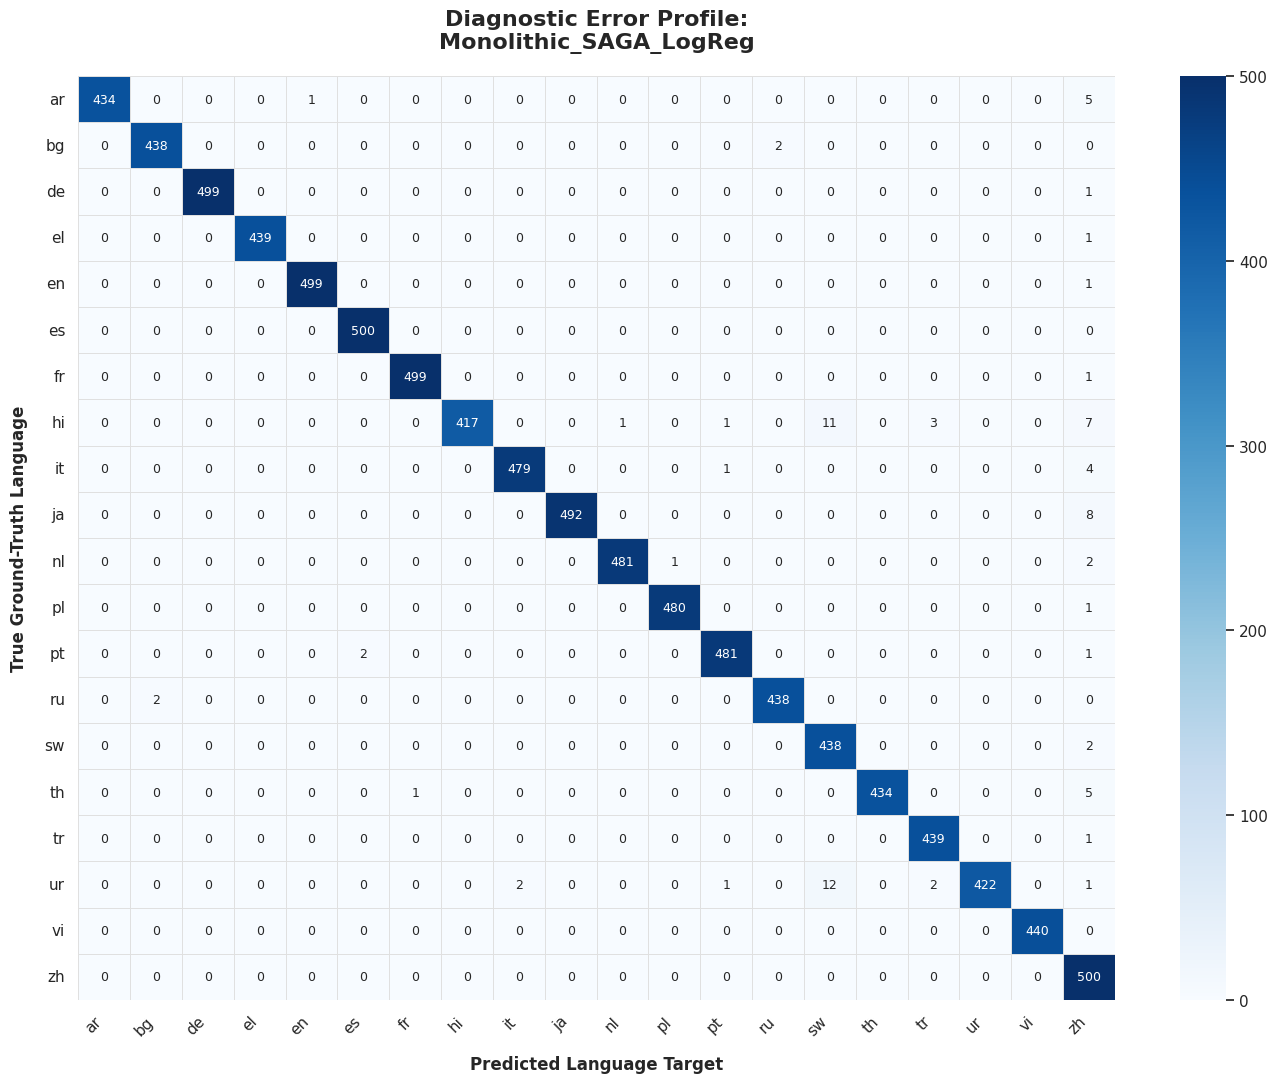

------------------------------------------------------------

Evaluating Hierarchical_Traditional...


Inference: Hierarchical_Traditional:   0%|          | 0/9333 [00:00<?, ?it/s]


Classification Report for Hierarchical_Traditional:

              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       440
          bg       0.98      0.98      0.98       440
          de       1.00      1.00      1.00       500
          el       1.00      0.99      1.00       440
          en       0.99      1.00      1.00       500
          es       0.98      0.99      0.99       500
          fr       0.99      1.00      0.99       500
          hi       1.00      0.96      0.98       440
          it       0.98      0.98      0.98       484
          ja       1.00      1.00      1.00       500
          nl       0.99      0.97      0.98       484
          pl       0.80      0.99      0.88       481
          pt       0.98      0.98      0.98       484
          ru       0.99      0.96      0.97       440
          sw       0.99      0.98      0.98       440
          th       1.00      0.89      0.94       440
          tr       0.97    

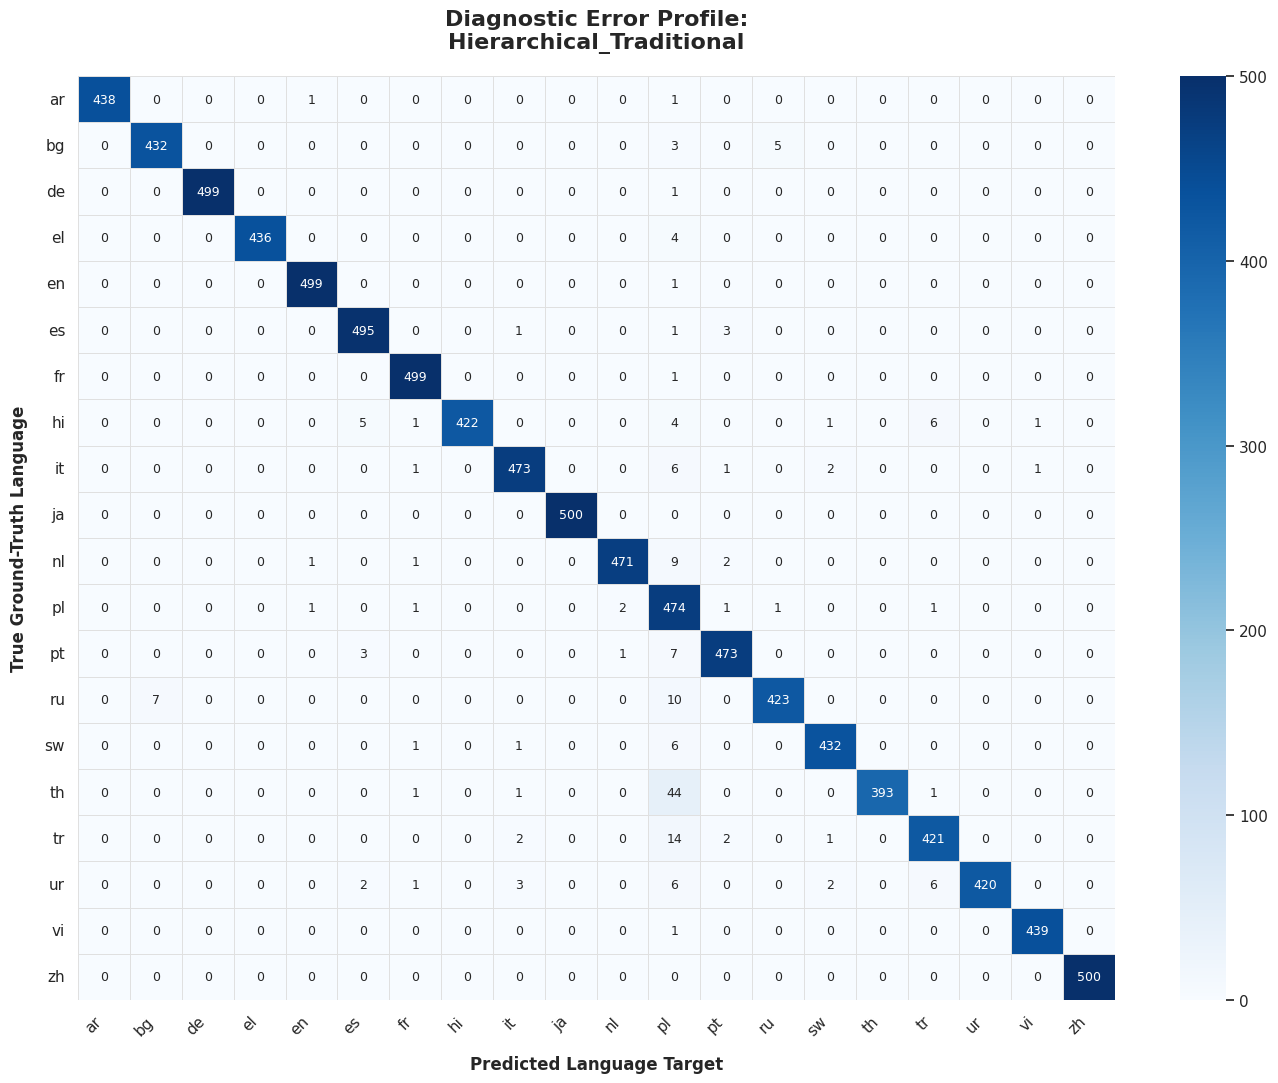

------------------------------------------------------------

Evaluating Monolithic_FastText...


Inference: Monolithic_FastText:   0%|          | 0/9333 [00:00<?, ?it/s]


Classification Report for Monolithic_FastText:

              precision    recall  f1-score   support

          ar       0.99      0.89      0.94       440
          bg       0.96      0.97      0.97       440
          de       1.00      0.99      0.99       500
          el       1.00      0.98      0.99       440
          en       0.99      0.98      0.99       500
          es       0.98      0.98      0.98       500
          fr       0.98      0.99      0.99       500
          hi       1.00      0.91      0.95       440
          it       0.99      0.97      0.98       484
          ja       0.11      0.04      0.05       500
          nl       0.99      0.98      0.98       484
          pl       0.95      0.94      0.94       481
          pt       0.95      0.97      0.96       484
          ru       0.99      0.89      0.94       440
          sw       0.99      0.92      0.95       440
          th       1.00      0.11      0.19       440
          tr       0.98      0.8

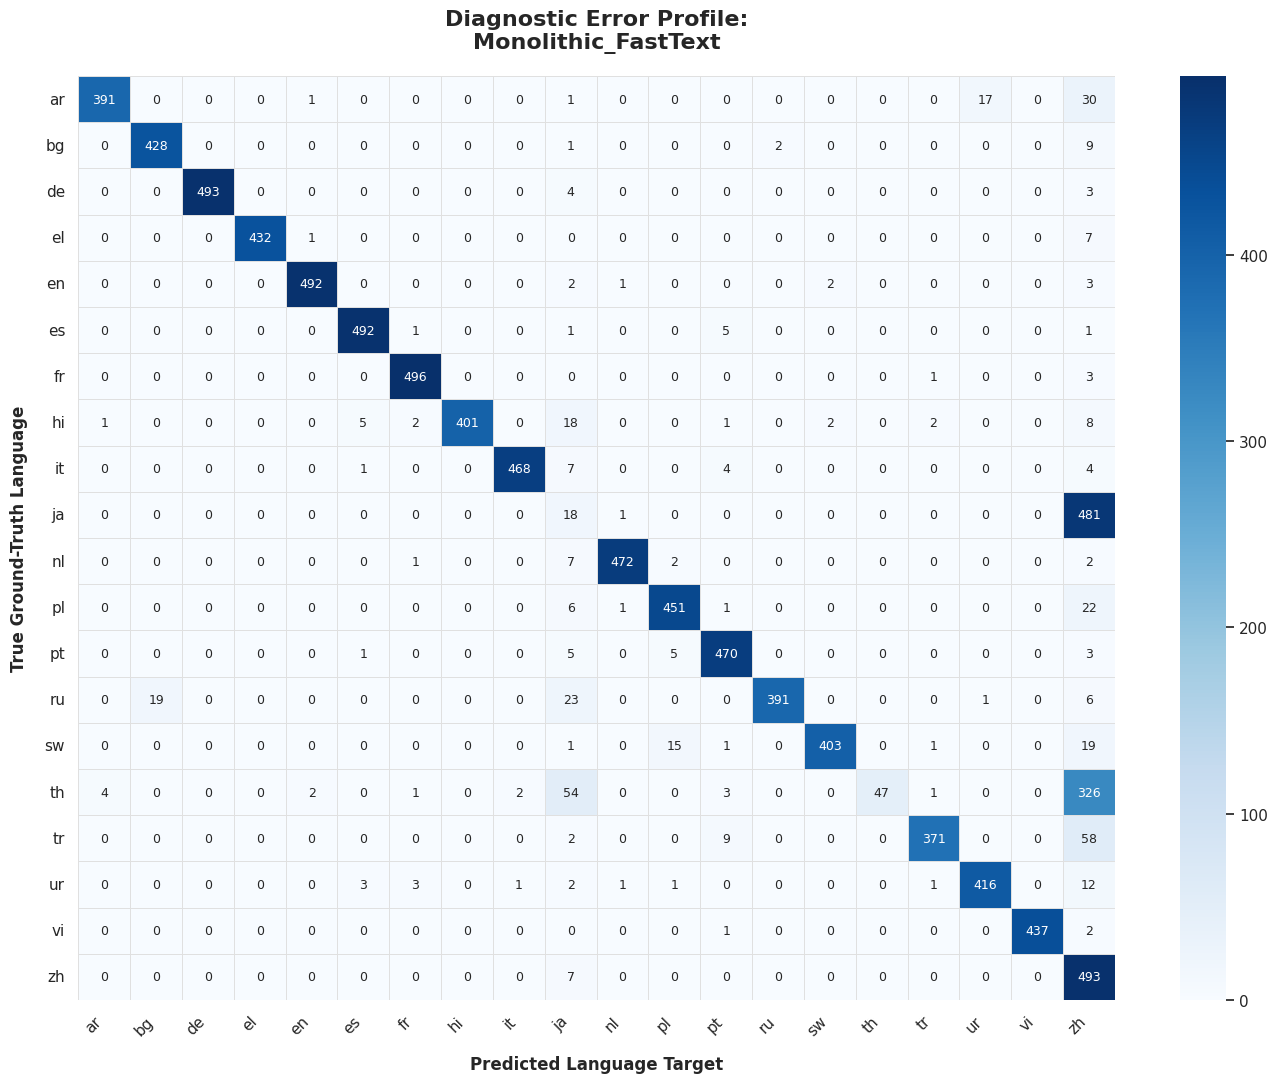

------------------------------------------------------------

Evaluating Hierarchical_FastText...


Inference: Hierarchical_FastText:   0%|          | 0/9333 [00:00<?, ?it/s]


Classification Report for Hierarchical_FastText:

              precision    recall  f1-score   support

          ar       1.00      0.93      0.97       440
          bg       0.97      0.95      0.96       440
          de       1.00      0.99      0.99       500
          el       1.00      0.98      0.99       440
          en       0.99      0.98      0.99       500
          es       0.98      0.98      0.98       500
          fr       0.99      0.99      0.99       500
          hi       1.00      0.96      0.98       440
          it       0.98      0.98      0.98       484
          ja       0.80      0.03      0.06       500
          nl       0.96      0.98      0.97       484
          pl       0.49      1.00      0.65       481
          pt       0.95      0.98      0.96       484
          ru       0.97      0.92      0.95       440
          sw       1.00      0.92      0.96       440
          th       0.99      0.19      0.31       440
          tr       0.98      0

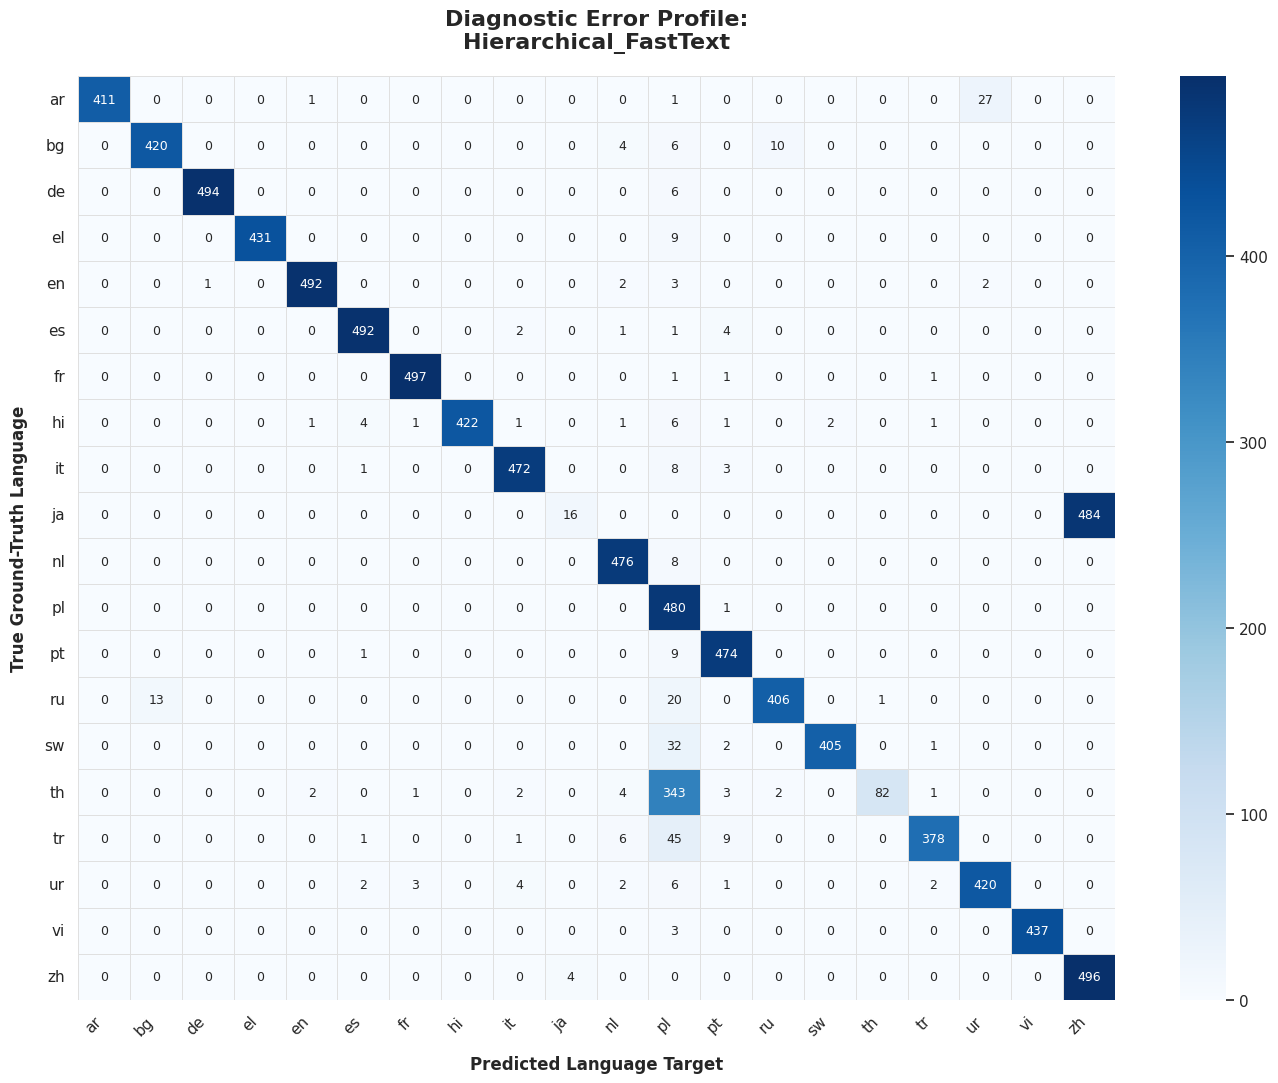

------------------------------------------------------------

Final Benchmark Summary Table:
                         Accuracy Avg Inference Latency (per query)
Monolithic_SAGA_LogReg     99.10%                          2.663 ms
Hierarchical_Traditional   97.92%                          1.180 ms
Monolithic_FastText        86.38%                          0.047 ms
Hierarchical_FastText      87.87%                          0.097 ms



,Accuracy,Avg Inference Latency (per query)
Monolithic_SAGA_LogReg,99.10%,2.663 ms
Hierarchical_Traditional,97.92%,1.180 ms
Monolithic_FastText,86.38%,0.047 ms
Hierarchical_FastText,87.87%,0.097 ms


In [36]:
summary_df = evaluate_system_models(models, test_cleaned)
display(summary_df)

STARTING SYSTEM EVALUATION PHASE

Evaluating Monolithic_SAGA_LogReg...


Inference: Monolithic_SAGA_LogReg:   0%|          | 0/9333 [00:00<?, ?it/s]


Classification Report for Monolithic_SAGA_LogReg:

              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       440
          bg       1.00      1.00      1.00       440
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       440
          en       1.00      1.00      1.00       500
          es       1.00      1.00      1.00       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.96      0.98       440
          it       1.00      1.00      1.00       484
          ja       1.00      1.00      1.00       500
          nl       1.00      1.00      1.00       484
          pl       1.00      1.00      1.00       481
          pt       1.00      1.00      1.00       484
          ru       1.00      1.00      1.00       440
          sw       0.93      1.00      0.96       440
          th       1.00      1.00      1.00       440
          tr       1.00      

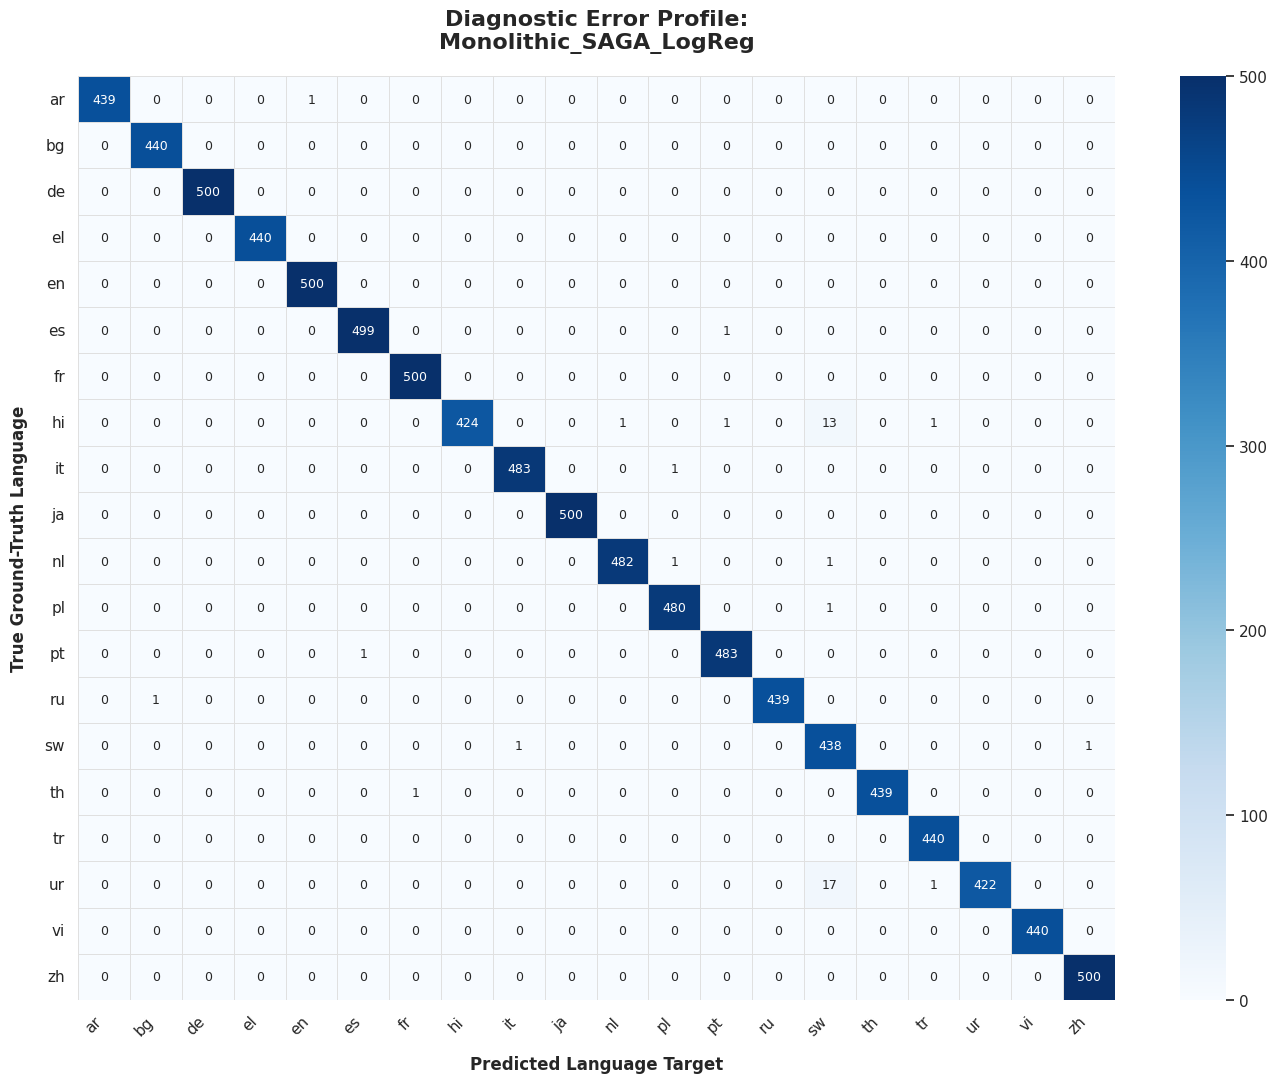

------------------------------------------------------------

Evaluating Hierarchical_Traditional...


Inference: Hierarchical_Traditional:   0%|          | 0/9333 [00:00<?, ?it/s]


Classification Report for Hierarchical_Traditional:

              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       440
          bg       0.98      0.98      0.98       440
          de       1.00      1.00      1.00       500
          el       1.00      0.99      1.00       440
          en       0.99      1.00      1.00       500
          es       0.98      0.99      0.99       500
          fr       0.99      1.00      0.99       500
          hi       1.00      0.96      0.98       440
          it       0.98      0.98      0.98       484
          ja       1.00      1.00      1.00       500
          nl       0.99      0.97      0.98       484
          pl       0.80      0.99      0.88       481
          pt       0.98      0.98      0.98       484
          ru       0.99      0.96      0.97       440
          sw       0.99      0.98      0.98       440
          th       1.00      0.90      0.94       440
          tr       0.97    

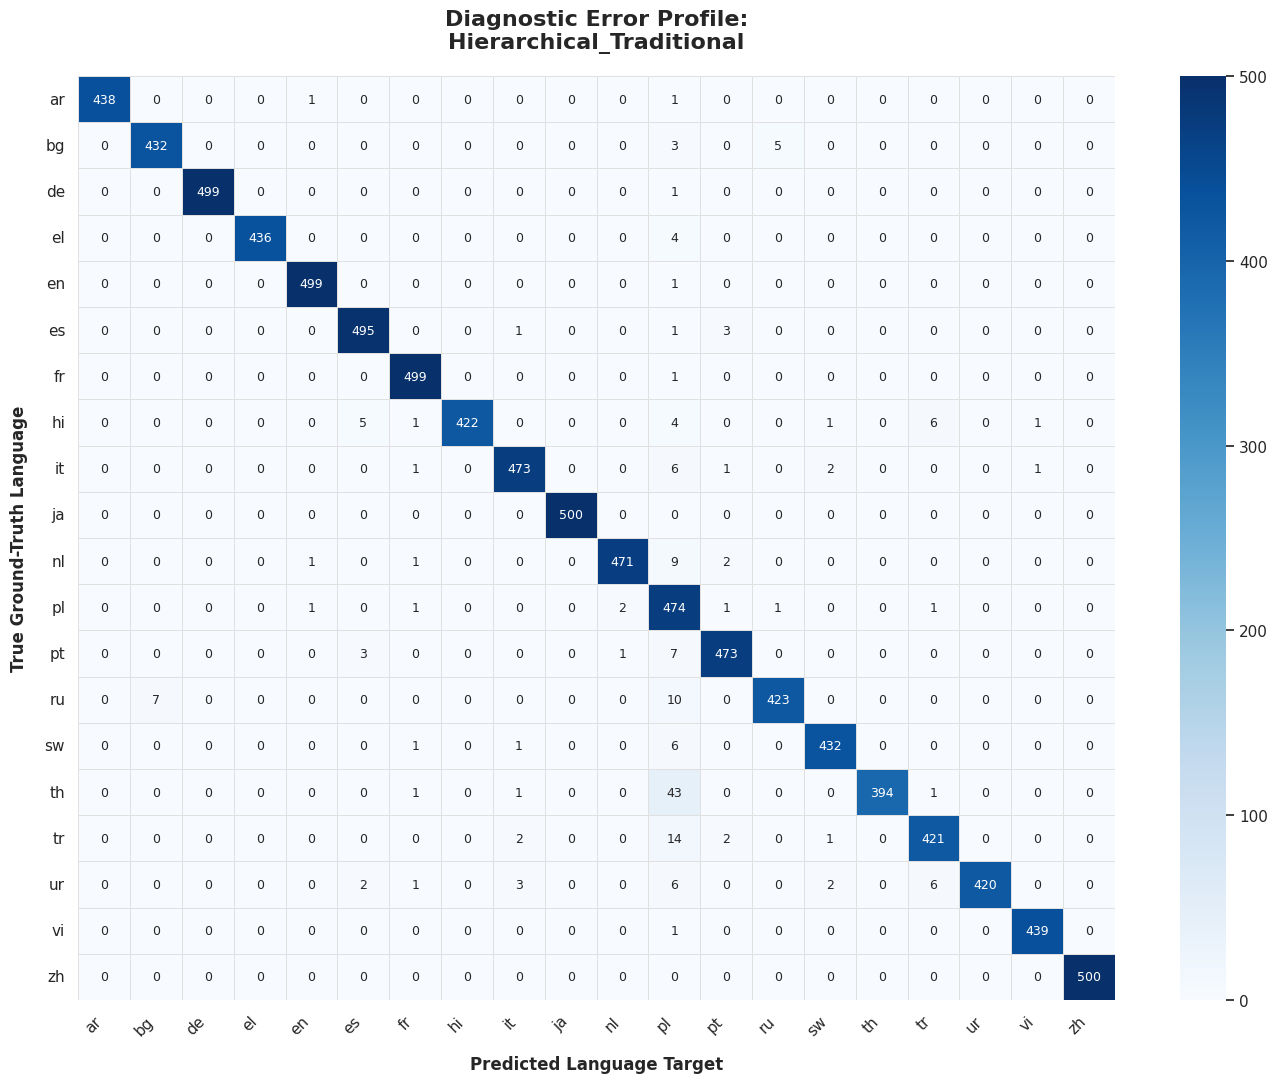

------------------------------------------------------------

Evaluating Monolithic_FastText...


Inference: Monolithic_FastText:   0%|          | 0/9333 [00:00<?, ?it/s]


Classification Report for Monolithic_FastText:

              precision    recall  f1-score   support

          ar       0.99      0.91      0.95       440
          bg       0.97      0.97      0.97       440
          de       1.00      0.99      0.99       500
          el       1.00      0.98      0.99       440
          en       0.99      0.99      0.99       500
          es       0.98      0.99      0.98       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.94      0.97       440
          it       0.98      0.98      0.98       484
          ja       0.17      0.02      0.04       500
          nl       0.99      0.99      0.99       484
          pl       0.98      0.95      0.97       481
          pt       0.96      0.98      0.97       484
          ru       0.99      0.92      0.95       440
          sw       0.99      0.95      0.97       440
          th       1.00      0.18      0.31       440
          tr       0.97      0.8

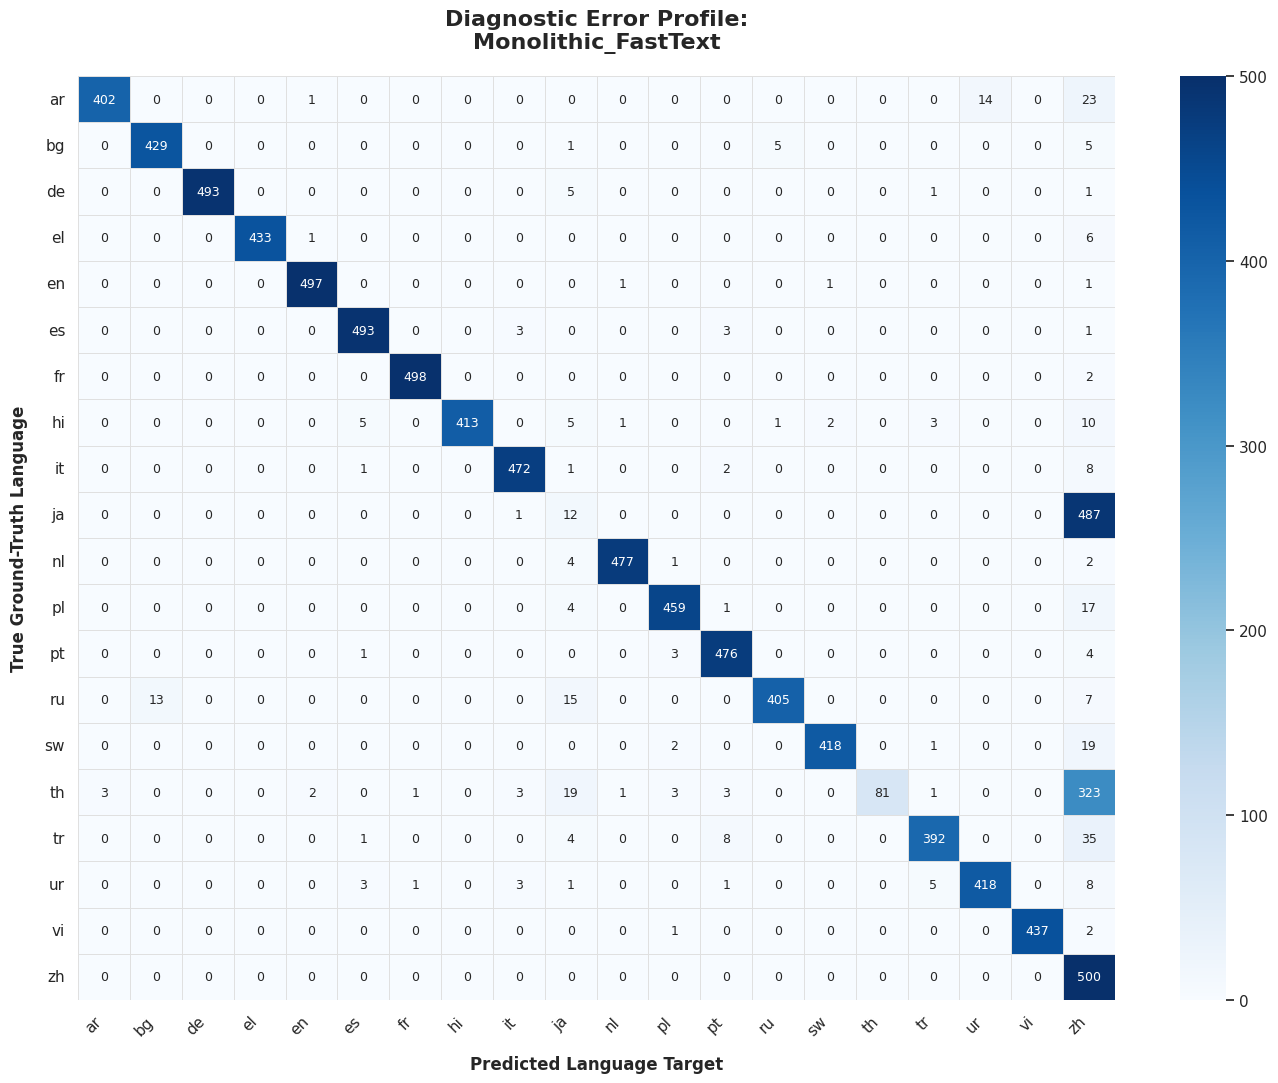

------------------------------------------------------------

Evaluating Hierarchical_FastText...


Inference: Hierarchical_FastText:   0%|          | 0/9333 [00:00<?, ?it/s]


Classification Report for Hierarchical_FastText:

              precision    recall  f1-score   support

          ar       1.00      0.93      0.97       440
          bg       0.97      0.95      0.96       440
          de       1.00      0.99      0.99       500
          el       1.00      0.98      0.99       440
          en       0.99      0.98      0.99       500
          es       0.98      0.98      0.98       500
          fr       0.99      0.99      0.99       500
          hi       1.00      0.96      0.98       440
          it       0.98      0.98      0.98       484
          ja       0.80      0.03      0.06       500
          nl       0.96      0.98      0.97       484
          pl       0.49      1.00      0.65       481
          pt       0.95      0.98      0.96       484
          ru       0.97      0.92      0.95       440
          sw       1.00      0.92      0.96       440
          th       0.99      0.19      0.31       440
          tr       0.98      0

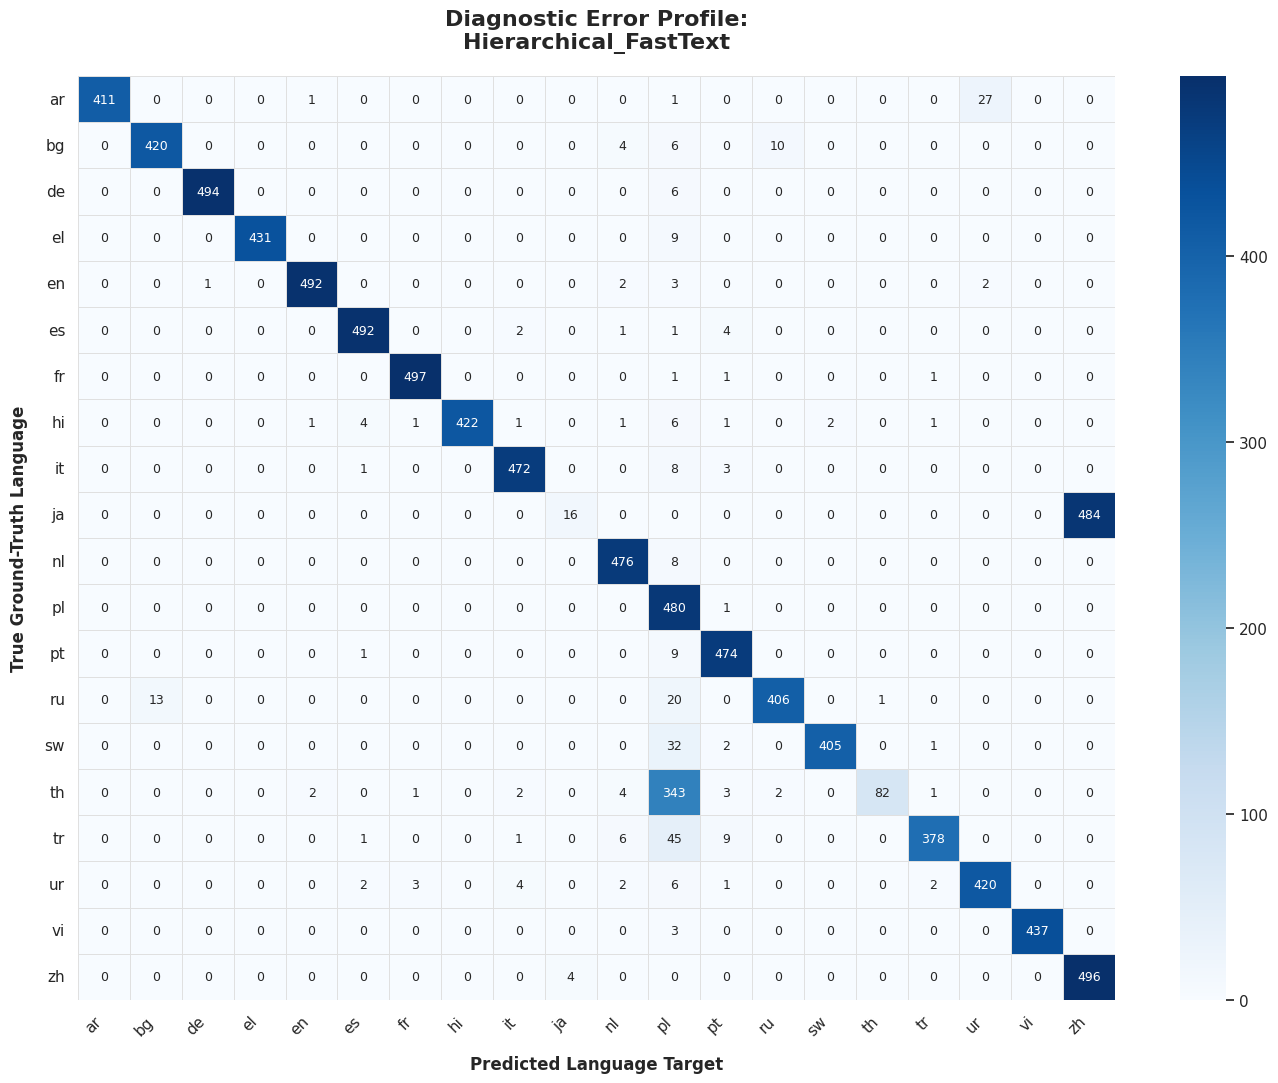

------------------------------------------------------------

Final Benchmark Summary Table:
                         Accuracy Avg Inference Latency (per query)
Monolithic_SAGA_LogReg     99.52%                          3.114 ms
Hierarchical_Traditional   97.93%                          1.255 ms
Monolithic_FastText        87.91%                          0.049 ms
Hierarchical_FastText      87.87%                          0.113 ms



,Accuracy,Avg Inference Latency (per query)
Monolithic_SAGA_LogReg,99.52%,3.114 ms
Hierarchical_Traditional,97.93%,1.255 ms
Monolithic_FastText,87.91%,0.049 ms
Hierarchical_FastText,87.87%,0.113 ms


In [37]:
summary_df = evaluate_system_models(production_suite, test_cleaned)
display(summary_df)

# Model Saving

In [38]:
import shutil

# 1. Establish the Production Directory Context Boundary
PROD_DIR = "production_artifacts"
os.makedirs(PROD_DIR, exist_ok=True)

# Define clean export destination mapping strings
export_blueprints = {
    "Monolithic_SAGA_LogReg": os.path.join(PROD_DIR, "mono_saga_pipeline.pkl"),
    "Hierarchical_Traditional": os.path.join(PROD_DIR, "hierarchical_traditional_pipeline.pkl"),
    "Monolithic_FastText": os.path.join(PROD_DIR, "mono_fasttext_model.bin"),
    "Hierarchical_FastText": os.path.join(PROD_DIR, "hierarchical_fasttext_bundle") # Directory track
}

In [39]:
for name, model in production_suite.items():
    print(f" -> Fitting architecture parameters for: [{name}]...")
    model.fit(train_df=train_cleaned, val_df=val_cleaned)

    # Run immediate validation-save routing execution
    destination = export_blueprints[name]
    print(f"    Exporting compiled states to storage target: {destination}")
    model.save(destination)

print("\nAll production configurations compiled and archived successfully.")
print("="*70 + "\n")

# Clean up local uncompiled cache elements
for cache_temp in ["temp_mono_ft.bin", "temp_hier_ft"]:
    if os.path.exists(cache_temp):
        if os.path.isdir(cache_temp): shutil.rmtree(cache_temp)
        else: os.remove(cache_temp)

 -> Fitting architecture parameters for: [Monolithic_SAGA_LogReg]...
    Exporting compiled states to storage target: production_artifacts/mono_saga_pipeline.pkl
 -> Fitting architecture parameters for: [Hierarchical_Traditional]...

=== Training Hierarchical TF-IDF + LogReg Pipeline ===
 -> Training Sub-Model: [ARABIC] | Samples: 6891
 -> Training Sub-Model: [CJK] | Samples: 6988
 -> Training Sub-Model: [LATIN] | Samples: 51402
    Exporting compiled states to storage target: production_artifacts/hierarchical_traditional_pipeline.pkl
 -> Fitting architecture parameters for: [Monolithic_FastText]...
    Exporting compiled states to storage target: production_artifacts/mono_fasttext_model.bin
 -> Fitting architecture parameters for: [Hierarchical_FastText]...

=== Training Hierarchical FastText Pipeline ===
 -> Training Sub-Model: [LATIN] | Samples: 51402
 -> Training Sub-Model: [ARABIC] | Samples: 6891
 -> Training Sub-Model: [CJK] | Samples: 6988
    Exporting compiled states to stora

# PRODUCTION DEPLOYMENT SIMULATION (ZERO-MEMORY INITIALIZATION)

In [40]:
print("="*70)
print("SIMULATING COLD-START DEPLOYMENT RETRIEVAL (PRODUCTION ENVIRONMENT)")
print("="*70)

# Flush old instances completely from session memory to guarantee no leak traces
del production_suite

# Re-initialize clean, un-trained structures to simulate cold deployment initializations
production_ready_endpoints = {
    "Monolithic_SAGA_LogReg": TraditionalMLDetector(),
    "Hierarchical_Traditional": HierarchicalTraditionalDetector(),
    "Monolithic_FastText": FastTextDetector(model_path="final_mono_ft.bin"), # Bound on setup load
    "Hierarchical_FastText": HierarchicalFastTextDetector()
}

# Perform static load recovery updates without running .fit()
for name, model in production_ready_endpoints.items():
    source_target = export_blueprints[name]
    print(f" -> Recovering structural parameters for [{name}] from: {source_target}")
    model.load(source_target)

print("\nAll production pipelines loaded successfully from disk. System online.")
print("="*70 + "\n")


# =====================================================================
# 4. OPERATIONAL INFRASTRUCTURE TESTS
# =====================================================================
print("Running diagnostic queries against recovered operational models...")

smoke_test_queries = [
    "The data engineering pipeline executed with zero exceptions or errors.",
    "Ce modèle de classification des langues est extrêmement rapide.",
    "تتطلب معالجة اللغة الطبيعية مصفوفات رياضية معقدة للحصول على دقة عالية.",
    "नमस्ते, यह भाषा वर्गीकरण प्रणाली सुचारू रूप से चल रही है।"
]

verification_records = []

for query in smoke_test_queries:
    row_entry = {"Input Text Query": f"'{query[:45]}...'"}
    for name, pipeline in production_ready_endpoints.items():
        # Confirming execution integrity
        row_entry[name] = pipeline.predict(query)
    verification_records.append(row_entry)

# Render complete verification dashboard table
output_dashboard = pd.DataFrame(verification_records)
print(output_dashboard.to_string(index=False))
print("\n" + "="*70)
print("VERIFICATION TESTING COMPLETE: ARTIFACTS VALIDATED FOR PRODUCTION")
print("="*70 + "\n")

SIMULATING COLD-START DEPLOYMENT RETRIEVAL (PRODUCTION ENVIRONMENT)
 -> Recovering structural parameters for [Monolithic_SAGA_LogReg] from: production_artifacts/mono_saga_pipeline.pkl
 -> Recovering structural parameters for [Hierarchical_Traditional] from: production_artifacts/hierarchical_traditional_pipeline.pkl
 -> Recovering structural parameters for [Monolithic_FastText] from: production_artifacts/mono_fasttext_model.bin
 -> Recovering structural parameters for [Hierarchical_FastText] from: production_artifacts/hierarchical_fasttext_bundle

All production pipelines loaded successfully from disk. System online.

Running diagnostic queries against recovered operational models...
                                  Input Text Query Monolithic_SAGA_LogReg Hierarchical_Traditional Monolithic_FastText Hierarchical_FastText
'The data engineering pipeline executed with z...'                     en                       en                  en                    en
'Ce modèle de classificati